# Alternating surface mass balance as a source of steep isochrones: n=3 flow

The n=3 ALHIC1901 inverse fit requires an initially ordered wrinkle with 10.3 m amplitude, 27.4 m horizontal wavelength, and an 81.1° maximum dip. This notebook tests whether alternating bands of accumulation and ablation can create that geometry before background shear folds it.

The workflow is unchanged from the linear-viscous test: resolve the surface-forced Stokes response, sweep mass-balance amplitude, wavelength, band speed, duration, and layer depth, and diagnose later folding. The surface response is now a numerical two-dimensional n=3 full-Stokes solution, while the later shear diagnostic uses the matching n=3 gravity-driven slab.

## Observational scales and model target

Stake measurements at Allan Hills give blue-ice ablation rates from 0.009 to 0.046 m yr$^{-1}$ and horizontal speeds below 0.1 m yr$^{-1}$. They also show a spatially complex pattern of accumulation and ablation associated with variable surface winds ([Spaulding et al., 2012](https://doi.org/10.3189/2012JoG11J176)). Independent measurements place Allan Hills sublimation near 0.03–0.05 m yr$^{-1}$ ([Dadic et al., 2013](https://doi.org/10.1002/jgrf.20098)). Elsewhere in East Antarctica, persistent wind scour has removed 16–18 m of firn at about 0.054 m water equivalent per year ([Lenaerts et al., 2015](https://doi.org/10.1002/2015GL065544)).

I therefore sweep mass-balance amplitudes from 0.01 to 0.05 m yr$^{-1}$ as the present-rate range and 0.10 to 0.30 m yr$^{-1}$ as deliberately aggressive windy end members. The latter are not an inferred Little Ice Age reconstruction. They test whether increasing wind-driven ablation changes the mechanical conclusion. The background speed is 0.014 m yr$^{-1}$, matching the 160 m-thick slab used in the ALHIC1901 fit and lying within the observed slow-flow regime.

## Two-dimensional n=3 Stokes response

Let $x$ be horizontal distance and $y$ be depth below a flat surface. The imposed surface mass balance is

$$a(x,t)=b\sin[k(x-ct)],$$

where positive $a$ is accumulation, $b$ is the mass-balance amplitude, $k=2\pi/\lambda$ is wavenumber, and $c$ is band-migration speed. In a periodic cell the perturbation velocity solves incompressible full Stokes with Glen exponent $n=3$. The surface velocity is $(u',v')=(0,a)$, the perturbation vanishes at 12 wavelengths depth, and pressure has zero-mean gauge. This is a kinematic Dirichlet end member: it imposes the surface-normal velocity needed to maintain a flat surface rather than solving a free surface or atmospheric flow.

The unit-cell equations are nondimensional. Pure Glen flow with velocity boundary conditions is homogeneous, so changing $b$ or $\lambda$ rescales velocity, length, stress, and pressure without changing the unit velocity shape. I therefore set nondimensional softness to one and use strain-rate regularization $10^{-3}$ in unit-gradient coordinates; softness affects the inferred stress, not the velocity used here. Five continuation solves from $n=1$ to $n=3$ stabilize Newton iteration. P2--P1 meshes differ by a factor of two in both directions.

Initially horizontal material layers are integrated through the dimensionalized velocity. A layer is called *ordered* when every marker remains below the surface and the final mapping from initial to final horizontal position remains positive. The calculation records layer amplitude, maximum dip, exposure, and the time required for later n=3 slab shear to rotate the adverse limb through vertical.

/home/firedrake/firedrake/lib/python3.12/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


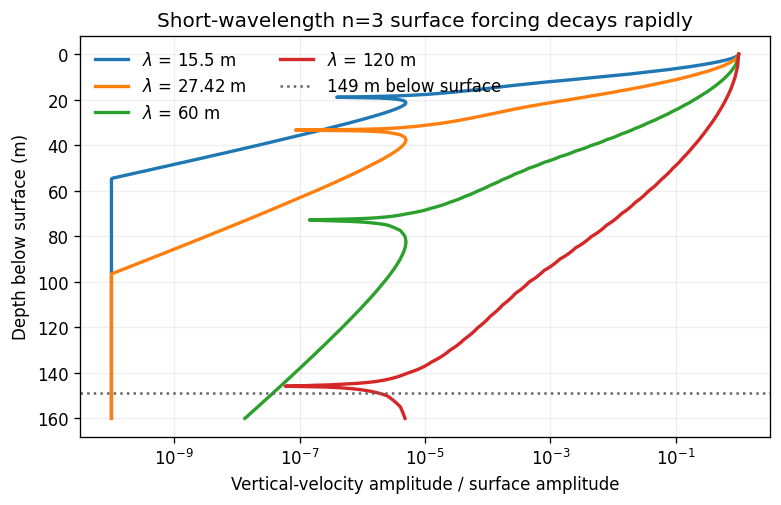

The calibrated 160 m slab softness is **2.146e-18 Pa$^{-3}$ yr$^{-1}$**, and its basal shear is **3.454e-04 yr$^{-1}$**. At 149 m below the surface, the n=3 unit response at 27.42 m wavelength is **1.1e-15** of its surface value. The factor-two Stokes meshes differ by at most **4.43e-03** in nondimensional velocity; their relative divergence measures are **9.99e-16** and **2.04e-15**.

In [1]:
import itertools
import logging
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
import firedrake as fd

warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")
logging.getLogger("tsfc").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

RHO, G, ALPHA = 917.0, 9.81, 0.03
SLAB_H = 160.0                   # m
GLEN_N = 3.0
REFERENCE_MU = 2.5e8             # Pa yr; retains earlier slab surface speed
DRIVING = RHO * G * np.sin(ALPHA)
U = DRIVING * SLAB_H**2 / (2 * REFERENCE_MU)
SLAB_SOFTNESS = U * (GLEN_N + 1) / (2 * DRIVING**GLEN_N * SLAB_H**(GLEN_N + 1))
BASAL_SHEAR = (GLEN_N + 1) * U / SLAB_H
UNIT_HEIGHT = 12.0               # wavelengths
UNIT_SOFTNESS = 1.0              # nondimensional; velocity is Dirichlet controlled
UNIT_EPS_REG = 1e-3              # nondimensional strain rate
TARGET_WAVELENGTH = 27.42        # m; n=3 ALHIC1901 inverse-fit seed
TARGET_AMPLITUDE = 10.3          # m
TARGET_DIP = 81.1                # degrees; n=3 ALHIC1901 inverse-fit seed
INITIAL_DEPTHS = np.array([2.0, 5.0, 10.0, 20.0])  # m below surface
OUTPUT_TIMES = (200.0, 500.0, 1000.0)              # yr

def solve_unit_stokes(nx, ny):
    mesh = fd.PeriodicRectangleMesh(nx, ny, 1.0, UNIT_HEIGHT, direction="x")
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    x, z = fd.SpatialCoordinate(mesh)
    y = UNIT_HEIGHT - z
    solution = fd.Function(mixed, name=f"surface_glen_n3_{nx}_{ny}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    top_velocity = fd.as_vector((0.0, -fd.sin(2 * np.pi * x)))
    bcs = [
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 1),
        fd.DirichletBC(mixed.sub(0), top_velocity, 2),
    ]
    k = 2 * np.pi
    initial_velocity = fd.as_vector((
        -k * y * fd.exp(-k * y) * fd.cos(k * x),
        -(1 + k * y) * fd.exp(-k * y) * fd.sin(k * x),
    ))
    solution.sub(0).interpolate(initial_velocity)
    solution.sub(1).assign(0.0)
    nullspace = fd.MixedVectorSpaceBasis(
        mixed, [mixed.sub(0), fd.VectorSpaceBasis(constant=True)]
    )
    for exponent in (1.0, 1.5, 2.0, 2.5, 3.0):
        strain = fd.sym(fd.grad(u))
        effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + UNIT_EPS_REG**2)
        viscosity = 0.5 * UNIT_SOFTNESS**(-1 / exponent) * effective_strain**(
            (1 - exponent) / exponent
        )
        residual = (
            2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
            - p * fd.div(v) - q * fd.div(u)
        ) * fd.dx
        fd.solve(
            residual == 0, solution, bcs=bcs, nullspace=nullspace,
            transpose_nullspace=nullspace,
            solver_parameters={
                "snes_type": "newtonls", "snes_linesearch_type": "bt",
                "snes_rtol": 1e-8, "snes_max_it": 60,
                "ksp_type": "preonly", "pc_type": "lu",
                "pc_factor_mat_solver_type": "mumps",
                "mat_mumps_icntl_24": 1, "mat_mumps_icntl_13": 1,
            },
        )
    velocity, pressure = solution.subfunctions
    divergence = fd.project(fd.div(velocity), Q)
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {"mesh": mesh, "velocity": velocity, "pressure": pressure,
            "divergence_ratio": div_l2 / grad_l2, "nx": nx, "ny": ny}

def velocity_grid(result, grid_x, grid_y):
    X, Y = np.meshgrid(grid_x, grid_y)
    points = np.column_stack((X.ravel(), UNIT_HEIGHT - Y.ravel()))
    values = np.asarray(result["velocity"].at(points, tolerance=1e-9)).reshape(
        len(grid_y), len(grid_x), 2
    )
    values[:, :, 1] *= -1.0  # vertical component positive downward
    return values

grid_x = np.linspace(0.0, 1.0, 97, endpoint=False)
grid_y = np.linspace(0.0, UNIT_HEIGHT, 289)
coarse = solve_unit_stokes(24, 144)
fine = solve_unit_stokes(48, 288)
coarse_grid = velocity_grid(coarse, grid_x, grid_y)
fine_grid = velocity_grid(fine, grid_x, grid_y)
stokes_mesh_difference = np.max(np.abs(fine_grid - coarse_grid))

def unit_velocity(xhat, yhat, field=fine_grid):
    xhat, yhat = np.broadcast_arrays(np.asarray(xhat, dtype=float), np.asarray(yhat, dtype=float))
    x_periodic = np.mod(xhat, 1.0)
    i_float = x_periodic * len(grid_x)
    i0 = np.floor(i_float).astype(int) % len(grid_x)
    i1 = (i0 + 1) % len(grid_x)
    fx = i_float - np.floor(i_float)
    y_clipped = np.clip(yhat, grid_y[0], grid_y[-1])
    j_float = (y_clipped - grid_y[0]) / (grid_y[1] - grid_y[0])
    j0 = np.minimum(np.floor(j_float).astype(int), len(grid_y) - 2)
    j1 = j0 + 1
    fy = np.minimum(j_float - j0, 1.0)
    values = (
        (1 - fx)[..., None] * (1 - fy)[..., None] * field[j0, i0]
        + fx[..., None] * (1 - fy)[..., None] * field[j0, i1]
        + (1 - fx)[..., None] * fy[..., None] * field[j1, i0]
        + fx[..., None] * fy[..., None] * field[j1, i1]
    )
    outside = (yhat < 0.0) | (yhat > UNIT_HEIGHT)
    return np.where(outside[..., None], 0.0, values)

def attenuation(depth, wavelength):
    scaled_depth = np.asarray(depth, dtype=float) / wavelength
    X, Y = np.meshgrid(grid_x, scaled_depth)
    return np.max(np.abs(unit_velocity(X, Y)[..., 1]), axis=1)

depth_axis = np.linspace(0.0, 160.0, 500)
fig, ax = plt.subplots(figsize=(6.4, 4.1), constrained_layout=True)
for wavelength in [15.5, TARGET_WAVELENGTH, 60.0, 120.0]:
    ax.semilogx(np.maximum(attenuation(depth_axis, wavelength), 1e-10), depth_axis, lw=2,
                label=f"$\lambda$ = {wavelength:g} m")
ax.axhline(149.0, color="0.4", ls=":", label="149 m below surface")
ax.invert_yaxis()
ax.set(xlabel="Vertical-velocity amplitude / surface amplitude",
       ylabel="Depth below surface (m)",
       title="Short-wavelength n=3 surface forcing decays rapidly")
ax.legend(frameon=False, ncol=2)
plt.show()

basal_attenuation = attenuation(np.array([149.0]), TARGET_WAVELENGTH)[0]
display(Markdown(
    f"The calibrated 160 m slab softness is **{SLAB_SOFTNESS:.3e} Pa$^{{-3}}$ yr$^{{-1}}$**, "
    f"and its basal shear is **{BASAL_SHEAR:.3e} yr$^{{-1}}$**. At 149 m below the surface, "
    f"the n=3 unit response at {TARGET_WAVELENGTH:.2f} m wavelength is **{basal_attenuation:.1e}** of its "
    f"surface value. The factor-two Stokes meshes differ by at most "
    f"**{stokes_mesh_difference:.2e}** in nondimensional velocity; their relative divergence "
    f"measures are **{coarse['divergence_ratio']:.2e}** and **{fine['divergence_ratio']:.2e}**."
))

In [2]:
def stokes_velocity(pattern_x, depth, rate, wavelength, migration_speed):
    response = unit_velocity(np.asarray(pattern_x) / wavelength, np.asarray(depth) / wavelength)
    horizontal = U - migration_speed + rate * response[..., 0]
    downward = rate * response[..., 1]
    return horizontal, downward

def layer_metrics(initial_x, pattern_x, depth, active, initial_depth):
    metrics = {
        "initial_depth": float(initial_depth),
        "surviving_fraction": float(np.mean(active)),
        "amplitude": np.nan, "dip": np.nan,
        "minimum_mapping": np.nan, "ordered": False,
    }
    if np.all(active):
        dx_dX = np.gradient(pattern_x, initial_x)
        dy_dX = np.gradient(depth, initial_x)
        minimum_mapping = float(np.min(dx_dX))
        metrics.update(
            amplitude=float(0.5 * np.ptp(depth)),
            dip=float(np.degrees(np.arctan(np.max(np.abs(dy_dX / dx_dX))))),
            minimum_mapping=minimum_mapping,
            ordered=minimum_mapping > 0.0,
        )
    return metrics

def simulate_history(rate, wavelength, speed_ratio, output_times=OUTPUT_TIMES,
                     depths=INITIAL_DEPTHS, nx=81, dt=2.0, return_states=False):
    initial_x = np.linspace(0.0, wavelength, nx)
    pattern_x = np.broadcast_to(initial_x, (len(depths), nx)).copy()
    depth = np.broadcast_to(np.asarray(depths)[:, None], pattern_x.shape).copy()
    active = np.ones_like(depth, dtype=bool)
    migration_speed = speed_ratio * U
    output_steps = {int(round(time / dt)): time for time in output_times}
    metrics, states = {}, {}

    for step in range(1, max(output_steps) + 1):
        k1x, k1y = stokes_velocity(pattern_x, depth, rate, wavelength, migration_speed)
        k2x, k2y = stokes_velocity(
            pattern_x + 0.5 * dt * k1x, depth + 0.5 * dt * k1y,
            rate, wavelength, migration_speed,
        )
        k3x, k3y = stokes_velocity(
            pattern_x + 0.5 * dt * k2x, depth + 0.5 * dt * k2y,
            rate, wavelength, migration_speed,
        )
        k4x, k4y = stokes_velocity(
            pattern_x + dt * k3x, depth + dt * k3y,
            rate, wavelength, migration_speed,
        )
        x_new = pattern_x + dt * (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        depth_new = depth + dt * (k1y + 2 * k2y + 2 * k3y + k4y) / 6
        newly_exposed = active & (depth_new <= 0.0)
        active[newly_exposed] = False
        pattern_x = np.where(active, x_new, pattern_x)
        depth = np.where(active, depth_new, 0.0)

        if step in output_steps:
            time = output_steps[step]
            metrics[time] = [
                layer_metrics(initial_x, pattern_x[j], depth[j], active[j], initial_depth)
                for j, initial_depth in enumerate(depths)
            ]
            if return_states:
                states[time] = {
                    "initial_x": initial_x.copy(), "pattern_x": pattern_x.copy(),
                    "depth": depth.copy(), "active": active.copy(),
                }
    return metrics, states

def seed_score(record):
    if not record["ordered"]:
        return 0.0
    return min(record["amplitude"] / TARGET_AMPLITUDE, 1.0) * min(record["dip"] / TARGET_DIP, 1.0)

## Parameter sweep

The sweep contains six mass-balance amplitudes, four wavelengths, nine migration speeds, three durations, and four initial layer depths: 2592 layer outcomes. Band speeds range from $-0.5U$ to $1.5U$; $c\approx U$ keeps ice beneath the same mass-balance phase. A relaxed acceptance box requires at least 8 m amplitude and 80° dip while the layer remains continuous and ordered. This is slightly less restrictive than the fitted 10.3 m and 81.1° target.

In [3]:
rates = np.array([0.01, 0.03, 0.05, 0.10, 0.20, 0.30])
wavelengths = np.array([15.5, TARGET_WAVELENGTH, 60.0, 120.0])
speed_ratios = np.array([-0.5, 0.0, 0.5, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5])
records = []
for rate, wavelength, speed_ratio in itertools.product(rates, wavelengths, speed_ratios):
    history, _ = simulate_history(rate, wavelength, speed_ratio)
    for time, layers in history.items():
        for layer in layers:
            record = {
                "rate": float(rate), "wavelength": float(wavelength),
                "speed_ratio": float(speed_ratio), "time": float(time), **layer,
            }
            record["score"] = seed_score(record)
            records.append(record)

ordered_records = [record for record in records if record["ordered"]]
acceptance_cases = [
    record for record in ordered_records
    if record["amplitude"] >= 8.0 and record["dip"] >= 80.0
]
best_present = max(
    (record for record in ordered_records if record["rate"] <= 0.05),
    key=lambda record: record["score"],
)
best_target_spacing = max(
    (record for record in ordered_records if record["rate"] <= 0.05
     and record["wavelength"] == TARGET_WAVELENGTH),
    key=lambda record: record["score"],
)
best_windy = max(
    (record for record in ordered_records if record["rate"] >= 0.10),
    key=lambda record: record["score"],
)
exposed_count = sum(record["surviving_fraction"] < 1.0 for record in records)
overturned_count = len(records) - len(ordered_records) - exposed_count

def compact_case(record):
    return (
        f"$b={record['rate']:.2f}$ m yr$^{{-1}}$, $\lambda={record['wavelength']:.1f}$ m, "
        f"$c/U={record['speed_ratio']:.1f}$, $T={record['time']:.0f}$ yr, "
        f"$y_0={record['initial_depth']:.0f}$ m: amplitude {record['amplitude']:.1f} m, "
        f"dip {record['dip']:.1f}°"
    )

display(Markdown(
    f"The sweep produced **{len(ordered_records)} ordered outcomes** and "
    f"**{exposed_count} exposed or truncated outcomes**, and **{overturned_count} smooth but "
    f"already overturned outcomes**. Exactly **{len(acceptance_cases)}** "
    f"ordered cases enter the relaxed 8 m, 80° acceptance box. The best present-rate "
    f"case is {compact_case(best_present)}. At the fitted wavelength, the best present-rate "
    f"case is {compact_case(best_target_spacing)}."
))

The sweep produced **917 ordered outcomes** and **1665 exposed or truncated outcomes**, and **10 smooth but already overturned outcomes**. Exactly **0** ordered cases enter the relaxed 8 m, 80° acceptance box. The best present-rate case is $b=0.05$ m yr$^{-1}$, $\lambda=27.4$ m, $c/U=0.0$, $T=500$ yr, $y_0=10$ m: amplitude 6.0 m, dip 87.8°. At the fitted wavelength, the best present-rate case is $b=0.05$ m yr$^{-1}$, $\lambda=27.4$ m, $c/U=0.0$, $T=500$ yr, $y_0=10$ m: amplitude 6.0 m, dip 87.8°.

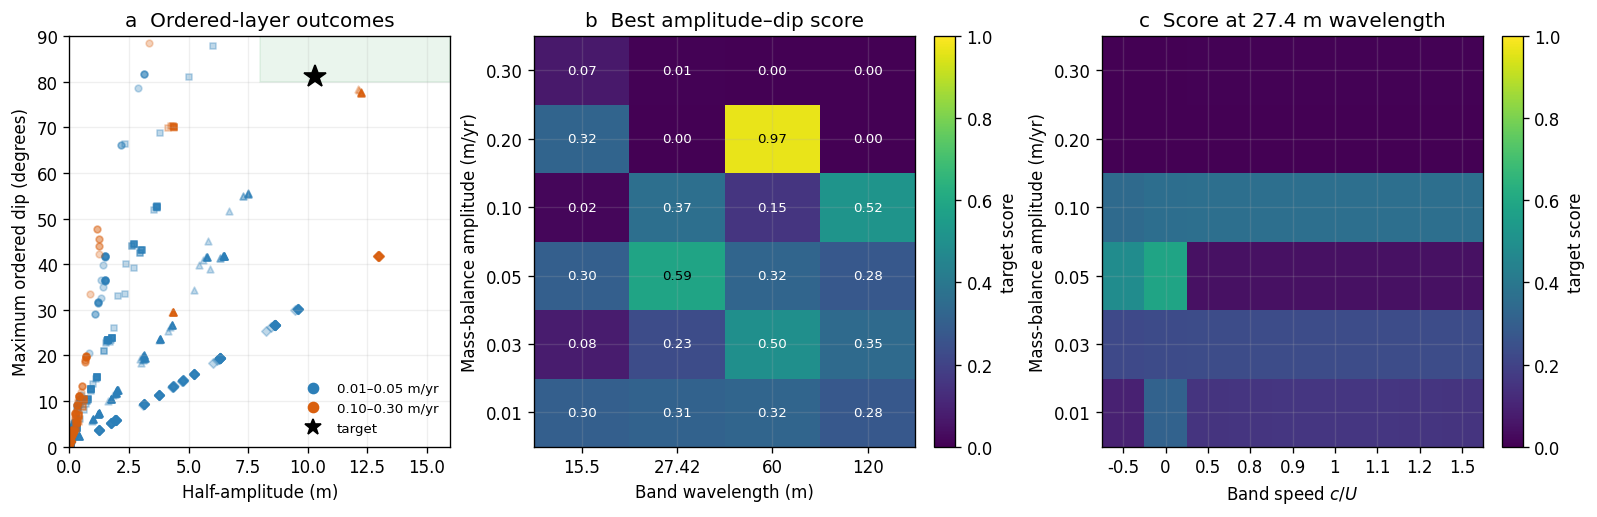

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), constrained_layout=True)

for wavelength, marker in zip(wavelengths, ["o", "s", "^", "D"]):
    current = [r for r in ordered_records if r["wavelength"] == wavelength and r["rate"] <= 0.05]
    windy = [r for r in ordered_records if r["wavelength"] == wavelength and r["rate"] >= 0.10]
    axes[0].scatter([r["amplitude"] for r in current], [r["dip"] for r in current],
                    s=16, marker=marker, color="#2c7fb8", alpha=0.30)
    axes[0].scatter([r["amplitude"] for r in windy], [r["dip"] for r in windy],
                    s=16, marker=marker, color="#d95f0e", alpha=0.28)
axes[0].add_patch(plt.Rectangle((8.0, 80.0), 8.0, 10.0, color="#31a354", alpha=0.10,
                                label="relaxed acceptance box"))
axes[0].plot(TARGET_AMPLITUDE, TARGET_DIP, marker="*", ms=14, color="black", label="inverse-fit target")
axes[0].set(xlabel="Half-amplitude (m)", ylabel="Maximum ordered dip (degrees)",
            title="a  Ordered-layer outcomes", xlim=(0, 16), ylim=(0, 90))
axes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color="#2c7fb8", label="0.01–0.05 m/yr"),
    Line2D([], [], marker="o", ls="", color="#d95f0e", label="0.10–0.30 m/yr"),
    Line2D([], [], marker="*", ls="", color="black", markersize=10, label="target"),
], frameon=False, fontsize=8)

best_score = np.zeros((len(rates), len(wavelengths)))
for i, rate in enumerate(rates):
    for j, wavelength in enumerate(wavelengths):
        best_score[i, j] = max(
            r["score"] for r in records
            if r["rate"] == rate and r["wavelength"] == wavelength
        )
image = axes[1].imshow(best_score, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis")
axes[1].set(xticks=np.arange(len(wavelengths)), xticklabels=[f"{w:g}" for w in wavelengths],
            yticks=np.arange(len(rates)), yticklabels=[f"{r:.2f}" for r in rates],
            xlabel="Band wavelength (m)", ylabel="Mass-balance amplitude (m/yr)",
            title="b  Best amplitude–dip score")
for i in range(len(rates)):
    for j in range(len(wavelengths)):
        axes[1].text(j, i, f"{best_score[i, j]:.2f}", ha="center", va="center",
                     color="white" if best_score[i, j] < 0.55 else "black", fontsize=8)
fig.colorbar(image, ax=axes[1], label="target score")

spacing_score = np.zeros((len(rates), len(speed_ratios)))
for i, rate in enumerate(rates):
    for j, speed_ratio in enumerate(speed_ratios):
        spacing_score[i, j] = max(
            r["score"] for r in records
            if r["rate"] == rate and r["wavelength"] == TARGET_WAVELENGTH
            and r["speed_ratio"] == speed_ratio
        )
image2 = axes[2].imshow(spacing_score, origin="lower", aspect="auto", vmin=0, vmax=1, cmap="viridis")
axes[2].set(xticks=np.arange(len(speed_ratios)), xticklabels=[f"{c:g}" for c in speed_ratios],
            yticks=np.arange(len(rates)), yticklabels=[f"{r:.2f}" for r in rates],
            xlabel="Band speed $c/U$", ylabel="Mass-balance amplitude (m/yr)",
            title=f"c  Score at {TARGET_WAVELENGTH:.1f} m wavelength")
fig.colorbar(image2, ax=axes[2], label="target score")
plt.show()

The parameter sweep shows a geometric tradeoff. Short bands make steep limbs but have insufficient vertical reach. Long bands make order-10 m relief but remain less steep. Increasing $b$ does not remove this tradeoff because near-surface layers are increasingly exposed in the ablation half-band, leaving only deeper and more weakly forced layers continuous. Band migration near the ice speed modestly increases residence time, but it does not produce the missing combination of amplitude and dip.

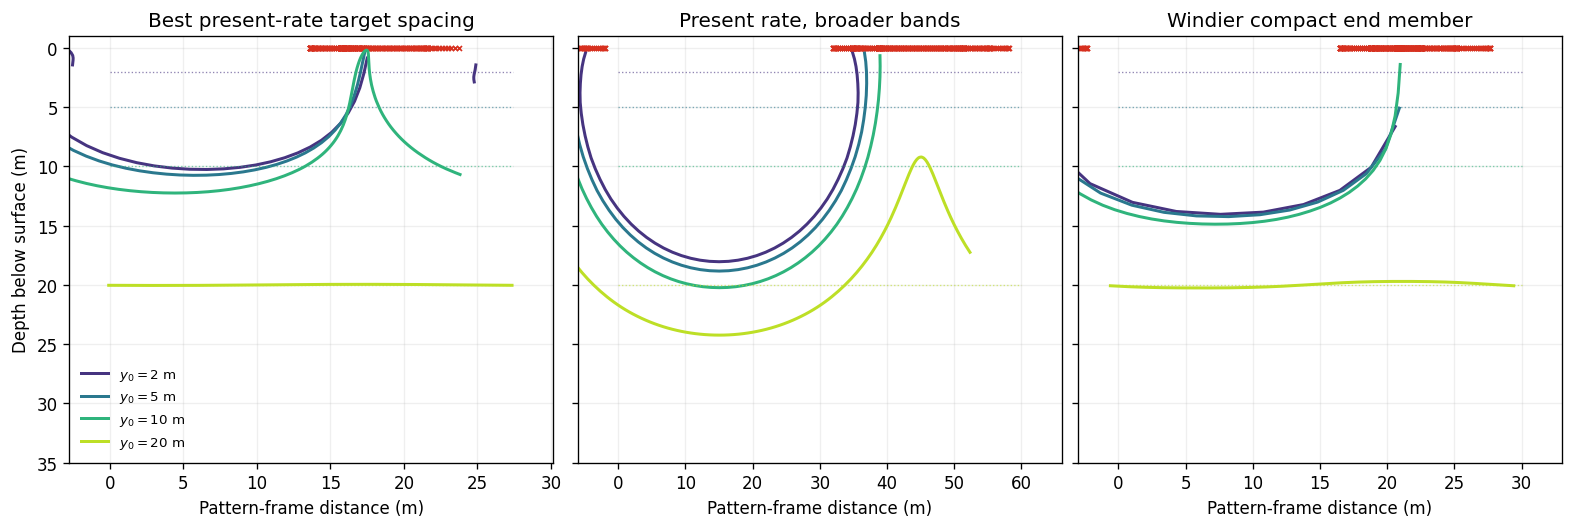

| Case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | Duration (yr) | Layer depth (m) | Amplitude (m) | Dip | Later fold time (kyr) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Best present-rate target spacing | 0.05 | 27.4 | 0.0 | 500 | 10 | 6.03 | 88.0° | 0.10 |
| Present rate, broader bands | 0.03 | 60.0 | 1.0 | 1000 | 20 | 7.51 | 55.4° | 1.99 |
| Windier compact end member | 0.30 | 30.0 | 0.0 | 200 | 20 | 0.28 | 4.1° | 40.62 |

In [5]:
case_specs = [
    {"name": "Best present-rate target spacing", "rate": 0.05, "wavelength": TARGET_WAVELENGTH,
     "speed_ratio": 0.0, "time": 500.0, "diagnostic_depth": 10.0},
    {"name": "Present rate, broader bands", "rate": 0.03, "wavelength": 60.0,
     "speed_ratio": 1.0, "time": 1000.0, "diagnostic_depth": 20.0},
    {"name": "Windier compact end member", "rate": 0.30, "wavelength": 30.0,
     "speed_ratio": 0.0, "time": 200.0, "diagnostic_depth": 20.0},
]
representative = []
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.3), constrained_layout=True, sharey=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(INITIAL_DEPTHS)))
for axis, spec in zip(axes, case_specs):
    history, states = simulate_history(
        spec["rate"], spec["wavelength"], spec["speed_ratio"],
        output_times=(spec["time"],), nx=161, dt=1.0, return_states=True,
    )
    state = states[spec["time"]]
    metrics = history[spec["time"]]
    selected = next(row for row in metrics if row["initial_depth"] == spec["diagnostic_depth"])
    representative.append({**spec, **selected})
    for j, (initial_depth, color) in enumerate(zip(INITIAL_DEPTHS, colors)):
        axis.plot(state["initial_x"], np.full_like(state["initial_x"], initial_depth),
                  ls=":", lw=0.8, color=color, alpha=0.6)
        offset = np.mean(state["pattern_x"][j] - state["initial_x"])
        aligned_x = state["pattern_x"][j] - offset
        active = state["active"][j]
        axis.plot(np.ma.masked_where(~active, aligned_x), np.ma.masked_where(~active, state["depth"][j]),
                  lw=1.8, color=color, label=f"$y_0={initial_depth:g}$ m")
        if np.any(~active):
            axis.plot(aligned_x[~active], np.zeros(np.count_nonzero(~active)), "x", color="#d7301f", ms=3)
    axis.set(xlabel="Pattern-frame distance (m)", title=spec["name"],
             xlim=(-0.1 * spec["wavelength"], 1.1 * spec["wavelength"]), ylim=(35, -1))
axes[0].set_ylabel("Depth below surface (m)")
axes[0].legend(frameon=False, fontsize=8)
plt.show()

table = [
    "| Case | $b$ (m yr$^{-1}$) | $\lambda$ (m) | $c/U$ | Duration (yr) | Layer depth (m) | Amplitude (m) | Dip | Later fold time (kyr) |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for case in representative:
    fold_time = 1 / (BASAL_SHEAR * np.tan(np.radians(case["dip"]))) / 1000
    table.append(
        f"| {case['name']} | {case['rate']:.2f} | {case['wavelength']:.1f} | "
        f"{case['speed_ratio']:.1f} | {case['time']:.0f} | {case['initial_depth']:.0f} | "
        f"{case['amplitude']:.2f} | {case['dip']:.1f}° | {fold_time:.2f} |"
    )
display(Markdown("\n".join(table)))

The dotted lines are initially horizontal layers; colored lines show surviving material after the mass-balance episode. Red crosses mark exposed material and therefore a surface truncation rather than a smooth wrinkle. The fold time applies the finite-strain condition $1+t u_z m=0$ to the adverse limb, using the basal shear from the speed-matched 160 m, n=3 full-Stokes slab. It is a second-stage diagnostic, not part of the surface-forcing calculation.

In [6]:
convergence_rows = []
for case in case_specs[:2]:
    coarse_history, _ = simulate_history(
        case["rate"], case["wavelength"], case["speed_ratio"],
        output_times=(case["time"],), nx=81, dt=2.0,
    )
    fine_history, _ = simulate_history(
        case["rate"], case["wavelength"], case["speed_ratio"],
        output_times=(case["time"],), nx=161, dt=1.0,
    )
    coarse_layer = next(row for row in coarse_history[case["time"]]
                        if row["initial_depth"] == case["diagnostic_depth"])
    fine_layer = next(row for row in fine_history[case["time"]]
                      if row["initial_depth"] == case["diagnostic_depth"])
    convergence_rows.append((case["name"], coarse_layer, fine_layer))

convergence_table = [
    "| Case | Coarse/fine amplitude (m) | Coarse/fine dip |",
    "|---|---:|---:|",
]
for name, coarse_layer, fine_layer in convergence_rows:
    convergence_table.append(
        f"| {name} | {coarse_layer['amplitude']:.3f}/{fine_layer['amplitude']:.3f} | "
        f"{coarse_layer['dip']:.2f}°/{fine_layer['dip']:.2f}° |"
    )
display(Markdown("\n".join(convergence_table)))

| Case | Coarse/fine amplitude (m) | Coarse/fine dip |
|---|---:|---:|
| Best present-rate target spacing | 6.028/6.028 | 87.84°/87.98° |
| Present rate, broader bands | 7.513/7.513 | 55.37°/55.44° |

## Interpretation

Alternating accumulation and ablation can produce a useful Waddington seed in an n=3 material. The parameter sweep tests whether measured-rate or deliberately windy surface forcing can make an initially ordered disturbance that later gravity-driven shear can overturn.

The calculation remains a mechanism test rather than a reconstruction. The surface boundary is held flat, the forcing is sinusoidal and periodic, and the n=3 unit cell uses a stated regularization. Because a velocity-driven pure power-law cell is scale invariant, its velocity shape can be reused across the sweep, but this also means the calculation does not predict the atmospheric traction required for each end member.

The depth-attenuation test is decisive for direct forcing: a 27.4 m surface pattern is negligible at the present ALHIC1901 fold depth. Any smooth seed made this way must have formed while the relevant ice was near the surface and then entered the deeper shear zone. Exposure instead creates a scour unconformity. A unified history should therefore fit surface-forcing parameters and later n=3 shear together rather than treating the fitted basal wrinkle as an unexplained initial condition.